# Bank Loan Approval Prediction Using Data Science and Machine Learning 

## OVERVIEW
Banks receive numerous loan applications daily. Evaluating these applications manually is time-consuming and prone to human error. This project aims to develop a Machine Learning model that predicts whether a loan application should be approved based on the applicant's financial and personal details. 
The project will cover the complete Data Science lifecycle, including data collection, preprocessing, exploratory data analysis, visualization, model development, evaluation, and interpretation. 


## OBJECTIVES
•	Understand the Data Science lifecycle.  
•	Perform data cleaning and preprocessing.  
•	Conduct exploratory data analysis (EDA).  
•	Visualize data using multiple visualization tools.  
•	Build Machine Learning models.  
•	Compare model performance.  
•	Predict loan approval status.  
•	Interpret and communicate findings. 

## DATA COLLECTION

### IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

#### Description: The required Python libraries are imported for data manipulation, data visualization, preprocessing, machine learning model building, and model evaluation.

### LOAD DATASET

In [2]:
df = pd.read_excel(r"C:\PYTHON\Loan_Applicants_1000.xlsx")

#### Description: The Loan Applicants Dataset is loaded into a Pandas DataFrame for further analysis and preprocessing.

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP100000,Male,No,1,Not Graduate,No,13164,6964,382,120,1,Semiurban,Y
1,LP100001,Female,Yes,1,Not Graduate,No,9719,13161,50,360,1,Rural,Y
2,LP100002,Male,Yes,0,Graduate,No,24964,14635,237,300,1,Semiurban,Y
3,LP100003,Male,No,0,Not Graduate,Yes,19869,8075,105,360,1,Semiurban,Y
4,LP100004,Male,No,0,Graduate,No,11213,13913,596,360,1,Rural,Y


#### Description : The df.head() function displays the first five rows of the dataset.

In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 1000
Number of Columns: 13


#### Description : The dataset contains 1000 records and 13 columns. These columns represent the applicant details and loan-related information used for loan approval prediction.

In [5]:
print(df.columns.tolist())

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


#### Description : The output displays all the column names available in the dataset. These columns contain demographic, financial, credit, property, and loan status information.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Loan_ID            1000 non-null   str  
 1   Gender             1000 non-null   str  
 2   Married            1000 non-null   str  
 3   Dependents         1000 non-null   str  
 4   Education          1000 non-null   str  
 5   Self_Employed      1000 non-null   str  
 6   ApplicantIncome    1000 non-null   int64
 7   CoapplicantIncome  1000 non-null   int64
 8   LoanAmount         1000 non-null   int64
 9   Loan_Amount_Term   1000 non-null   int64
 10  Credit_History     1000 non-null   int64
 11  Property_Area      1000 non-null   str  
 12  Loan_Status        1000 non-null   str  
dtypes: int64(5), str(8)
memory usage: 101.7 KB


#### Description : The info() function provides information about the dataset, including the number of records, column names, data types, and non-null values.

In [7]:
df.dtypes

Loan_ID                str
Gender                 str
Married                str
Dependents             str
Education              str
Self_Employed          str
ApplicantIncome      int64
CoapplicantIncome    int64
LoanAmount           int64
Loan_Amount_Term     int64
Credit_History       int64
Property_Area          str
Loan_Status            str
dtype: object

## DATA PREPROCESSING

### MISSING VALUES

In [8]:
df.isnull().sum()

print("Total Missing Values:",
      df.isnull().sum().sum())

Total Missing Values: 0


#### Description : The output shows the number of missing values present in each column. All columns contain 0 missing values, indicating that the dataset does not contain any null values.

### DUPLICATE VALUES

In [9]:
print("Duplicate Rows:",
      df.duplicated().sum())

Duplicate Rows: 0


#### Description : The output shows the number of duplicate rows present in the dataset. The result shows 0 duplicate rows, indicating that the dataset does not contain duplicate records.

### REMOVE DUPLICATES

In [10]:
df = df.drop_duplicates()

print("Shape after removing duplicates:",
      df.shape)

Shape after removing duplicates: (1000, 13)


#### Description : Duplicate records are removed from the dataset. Since no duplicate rows were found, the dataset size remains 1000 rows and 13 columns.

### UNIQUE VALUE ANALYSIS

In [11]:
for column in df.columns:
    print("\n", column)
    print(df[column].unique())


 Loan_ID
<StringArray>
['LP100000', 'LP100001', 'LP100002', 'LP100003', 'LP100004', 'LP100005',
 'LP100006', 'LP100007', 'LP100008', 'LP100009',
 ...
 'LP100990', 'LP100991', 'LP100992', 'LP100993', 'LP100994', 'LP100995',
 'LP100996', 'LP100997', 'LP100998', 'LP100999']
Length: 1000, dtype: str

 Gender
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

 Married
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

 Dependents
<StringArray>
['1', '0', '2', '3+']
Length: 4, dtype: str

 Education
<StringArray>
['Not Graduate', 'Graduate']
Length: 2, dtype: str

 Self_Employed
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

 ApplicantIncome
[13164  9719 24964 19869 11213  9988  3681 13094 20180  8664 20481  2401
 23944 10790 19561  4381 14558  7122  2878 19132  7150 13933 23963 10956
  8536  7987 18942 19932 23999  5748 20360  6103 21437 14132  1720 15726
  6318 22507  8849  7118 11356  6076 19755 16707  2962 23405 17405 17752
  9736  9313  3568  7253  8737 15675 24900  7691 19398

#### Description : The output displays the unique values present in each column. This helps to understand the different categories and possible values in the dataset before performing data transformation and encoding.

### DEPENDENTS DATA CONVERSION

In [12]:
df['Dependents'] = df['Dependents'].replace(
    '3+', '3')

df['Dependents'] = pd.to_numeric(
    df['Dependents'])

df['Dependents'].unique()

array([1, 0, 2, 3])

#### Description : The Dependents column contains the value 3+, which is converted to 3. The column is then converted into numeric format. The resulting unique values are 0, 1, 2, and 3.

### OUTLIER DETECTION

In [13]:
numerical_columns = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
]

numerical_columns

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

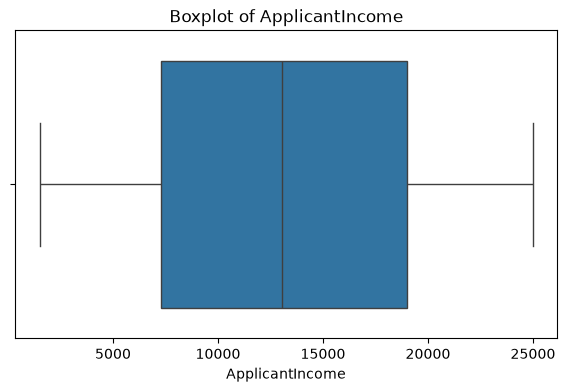

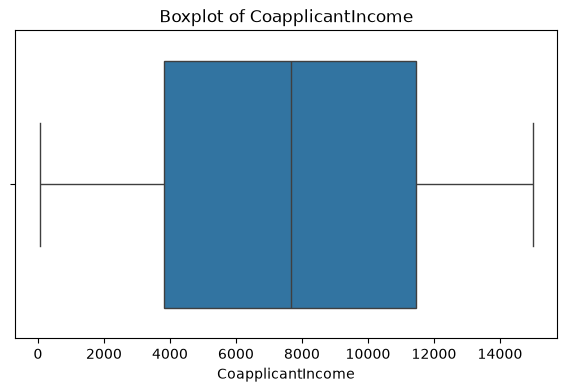

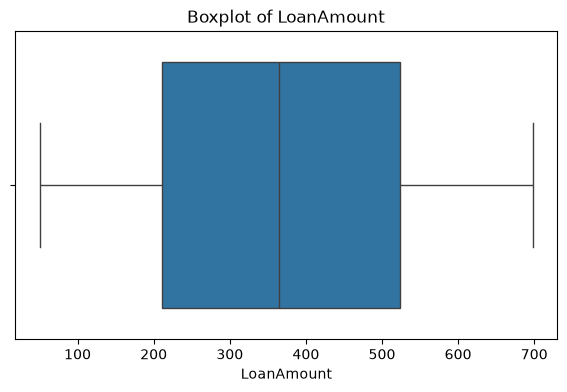

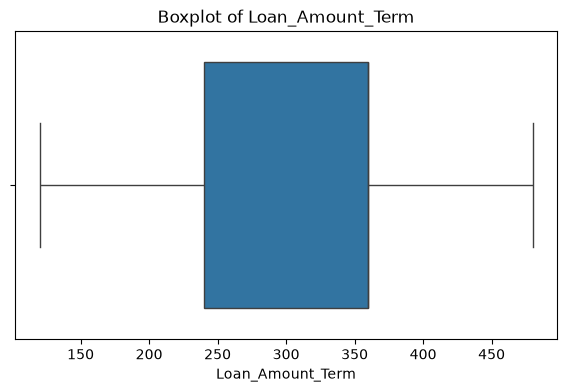

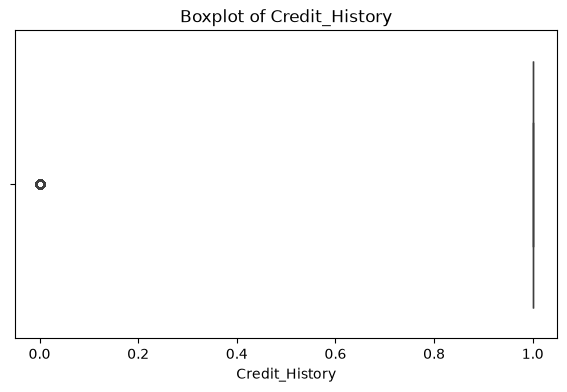

In [14]:
for column in numerical_columns:

    plt.figure(figsize=(7, 4))

    sns.boxplot(x=df[column])

    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)

    plt.show()

#### Description : Boxplots are used to identify the presence of outliers in numerical columns. The boxplots help visualize the spread of the data and identify values that are significantly different from the normal range.

## DATA TRANSFORMATION

### LABEL ENCODING

In [15]:
df_label = df.copy()

label_encoder = LabelEncoder()

label_columns = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Loan_Status'
]

for column in label_columns:

    df_label[column] = label_encoder.fit_transform(
        df_label[column]
    )

df_label.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP100000,1,0,1,1,0,13164,6964,382,120,1,Semiurban,1
1,LP100001,0,1,1,1,0,9719,13161,50,360,1,Rural,1
2,LP100002,1,1,0,0,0,24964,14635,237,300,1,Semiurban,1
3,LP100003,1,0,0,1,1,19869,8075,105,360,1,Semiurban,1
4,LP100004,1,0,0,0,0,11213,13913,596,360,1,Rural,1


#### Description : Label Encoding converts categorical values into numerical values so that they can be processed by machine learning algorithms.

In [16]:
for column in label_columns:

    print(
        column,
        ":",
        df_label[column].unique()
    )

Gender : [1 0]
Married : [0 1]
Education : [1 0]
Self_Employed : [0 1]
Loan_Status : [1 0]


#### Description : The output displays the numerical values assigned to the categorical variables after Label Encoding. This confirms that the selected categorical columns have been successfully converted into numerical form.

### ONE-HOT ENCODING

In [17]:
df_onehot = df.copy()

df_onehot = pd.get_dummies(
    df_onehot,
    columns=['Property_Area'],
    drop_first=True)

df_onehot.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,LP100000,Male,No,1,Not Graduate,No,13164,6964,382,120,1,Y,True,False
1,LP100001,Female,Yes,1,Not Graduate,No,9719,13161,50,360,1,Y,False,False
2,LP100002,Male,Yes,0,Graduate,No,24964,14635,237,300,1,Y,True,False
3,LP100003,Male,No,0,Not Graduate,Yes,19869,8075,105,360,1,Y,True,False
4,LP100004,Male,No,0,Graduate,No,11213,13913,596,360,1,Y,False,False


#### Description : One-Hot Encoding converts the categorical Property_Area column into separate binary columns. drop_first=True removes one category to avoid redundant information.

In [18]:
print(df_onehot.columns.tolist())

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'Property_Area_Semiurban', 'Property_Area_Urban']


#### Description : The output confirms that the Property_Area categorical column has been transformed into separate binary columns such as Property_Area_Semiurban and Property_Area_Urban.

## FEATURE SCALING

### STANDARDIZATION

In [19]:
standard_scaler = StandardScaler()

df_standardized = df_label.copy()

df_standardized[numerical_columns] = (
    standard_scaler.fit_transform(
        df_standardized[numerical_columns]
    )
)

df_standardized.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP100000,1,0,1,1,0,-0.002565,-0.140149,0.069945,-2.144661,0.439679,Semiurban,1
1,LP100001,0,1,1,1,0,-0.505726,1.277873,-1.718406,0.510444,0.439679,Rural,1
2,LP100002,1,1,0,0,0,1.720891,1.615160,-0.711112,-0.153332,0.439679,Semiurban,1
3,LP100003,1,0,0,1,1,0.976738,0.114075,-1.422143,0.510444,0.439679,Semiurban,1
4,LP100004,1,0,0,0,0,-0.287519,1.449949,1.222677,0.510444,0.439679,Rural,1


#### Description : Standardization transforms numerical features so that they have a mean close to 0 and a standard deviation close to 1. This helps machine learning algorithms handle numerical features on a similar scale.

In [20]:
df_standardized[numerical_columns].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,7.460699e-17,-2.842171e-17,7.283063e-17,-1.580958e-16,9.947598e-17
std,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00
min,-1.706011e+00,-1.722695e+00,-1.718406e+00,-2.144661e+00,-2.274388e+00
25%,-8.576835e-01,-8.623171e-01,-8.525099e-01,-8.171084e-01,4.396788e-01
50%,-2.125985e-02,2.391805e-02,-2.701379e-02,5.104438e-01,4.396788e-01
75%,8.490487e-01,8.896735e-01,8.308020e-01,5.104438e-01,4.396788e-01
max,1.724396e+00,1.697079e+00,1.772110e+00,1.837996e+00,4.396788e-01


### NORMALIZATION

In [21]:
minmax_scaler = MinMaxScaler()

df_normalized = df_label.copy()

df_normalized[numerical_columns] = (
    minmax_scaler.fit_transform(
        df_normalized[numerical_columns]
    )
)

df_normalized.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP100000,1,0,1,1,0,0.496573,0.462763,0.512346,0.000000,1.0,Semiurban,1
1,LP100001,0,1,1,1,0,0.349896,0.877417,0.000000,0.666667,1.0,Rural,1
2,LP100002,1,1,0,0,0,0.998978,0.976046,0.288580,0.500000,1.0,Semiurban,1
3,LP100003,1,0,0,1,1,0.782050,0.537103,0.084877,0.666667,1.0,Semiurban,1
4,LP100004,1,0,0,0,0,0.413505,0.927735,0.842593,0.666667,1.0,Rural,1


#### Description : Normalization is performed using MinMaxScaler to transform the numerical features into a common range between 0 and 1. This helps bring different numerical variables to a similar scale and makes the data suitable for further analysis and machine learning.

In [22]:
df_normalized[numerical_columns].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.497320,0.503745,0.492307,0.538500,0.838000
std,0.291656,0.292563,0.286634,0.251214,0.368635
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.247296,0.251589,0.248071,0.333333,1.000000
50%,0.491123,0.510739,0.484568,0.666667,1.000000
75%,0.744827,0.763901,0.730324,0.666667,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


## EXPLORATORY DATA ANALYSIS

### DESCRIPTIVE STATISTICS

In [23]:
df.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.938000,13181.560000,7576.474000,369.015000,313.860000,0.838000
std,1.002577,6850.136059,4372.358649,185.738821,90.437157,0.368635
min,0.000000,1501.000000,48.000000,50.000000,120.000000,0.000000
25%,0.000000,7309.250000,3808.000000,210.750000,240.000000,1.000000
50%,1.000000,13036.000000,7681.000000,364.000000,360.000000,1.000000
75%,2.000000,18994.750000,11464.500000,523.250000,360.000000,1.000000
max,3.000000,24988.000000,14993.000000,698.000000,480.000000,1.000000


#### Description : Descriptive statistics are used to understand the basic characteristics of the numerical variables. The output provides values such as mean, standard deviation, minimum, maximum, and quartiles for the dataset.

In [24]:
df.describe(include='object')

,Loan_ID,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status
count,1000,1000,1000,1000,1000,1000,1000
unique,1000,2,2,2,2,3,2
top,LP100000,Female,Yes,Graduate,No,Urban,Y
freq,1,510,644,752,841,388,959


In [25]:
df['Loan_Status'].value_counts()

Loan_Status
Y    959
N     41
Name: count, dtype: int64

In [26]:
df['Loan_Status'].value_counts(
    normalize=True) * 100

Loan_Status
Y    95.9
N     4.1
Name: proportion, dtype: float64

### CORRELATION ANALYSIS

In [27]:
df_corr = df.copy()

# Label encode categorical columns
correlation_label_columns = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Loan_Status'
]

for column in correlation_label_columns:

    encoder = LabelEncoder()

    df_corr[column] = (
        encoder.fit_transform(
            df_corr[column]
        )
    )

# Convert Property_Area using One-Hot Encoding
df_corr = pd.get_dummies(
    df_corr,
    columns=['Property_Area'],
    drop_first=True
)

# Remove Loan_ID
df_corr = df_corr.drop(
    'Loan_ID',
    axis=1
)

df_corr.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,1,1,0,13164,6964,382,120,1,1,True,False
1,0,1,1,1,0,9719,13161,50,360,1,1,False,False
2,1,1,0,0,0,24964,14635,237,300,1,1,True,False
3,1,0,0,1,1,19869,8075,105,360,1,1,True,False
4,1,0,0,0,0,11213,13913,596,360,1,1,False,False


In [28]:
correlation_matrix = (
    df_corr.corr())

correlation_matrix

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
Gender,1.000000,-0.002340,-0.007226,-0.020937,0.049726,-0.034396,-0.007774,0.029456,-0.010875,0.050926,0.041261,0.005627,-0.000493
Married,-0.002340,1.000000,-0.046002,0.025573,0.009161,-0.020478,-0.048811,-0.035546,-0.021853,-0.032151,-0.027342,0.003310,0.026264
Dependents,-0.007226,-0.046002,1.000000,-0.006064,0.007799,0.000648,-0.002445,0.014218,-0.026945,0.043216,0.032501,0.038916,-0.008077
Education,-0.020937,0.025573,-0.006064,1.000000,-0.015400,0.023178,0.030281,-0.009327,-0.034258,-0.036602,-0.091461,-0.004640,0.022695
Self_Employed,0.049726,0.009161,0.007799,-0.015400,1.000000,-0.014899,0.010944,0.019188,0.009568,0.013048,0.007158,-0.014222,0.074683
ApplicantIncome,-0.034396,-0.020478,0.000648,0.023178,-0.014899,1.000000,-0.001570,0.024961,-0.000862,0.010807,0.265515,0.028318,0.003827
CoapplicantIncome,-0.007774,-0.048811,-0.002445,0.030281,0.010944,-0.001570,1.000000,-0.003801,-0.002546,0.001747,0.150029,0.048799,-0.002079
LoanAmount,0.029456,-0.035546,0.014218,-0.009327,0.019188,0.024961,-0.003801,1.000000,0.078556,0.058792,-0.032065,-0.007231,0.002876
Loan_Amount_Term,-0.010875,-0.021853,-0.026945,-0.034258,0.009568,-0.000862,-0.002546,0.078556,1.000000,-0.002843,-0.021856,-0.031886,-0.007666
Credit_History,0.050926,-0.032151,0.043216,-0.036602,0.013048,0.010807,0.001747,0.058792,-0.002843,1.000000,0.401833,0.009439,-0.011941


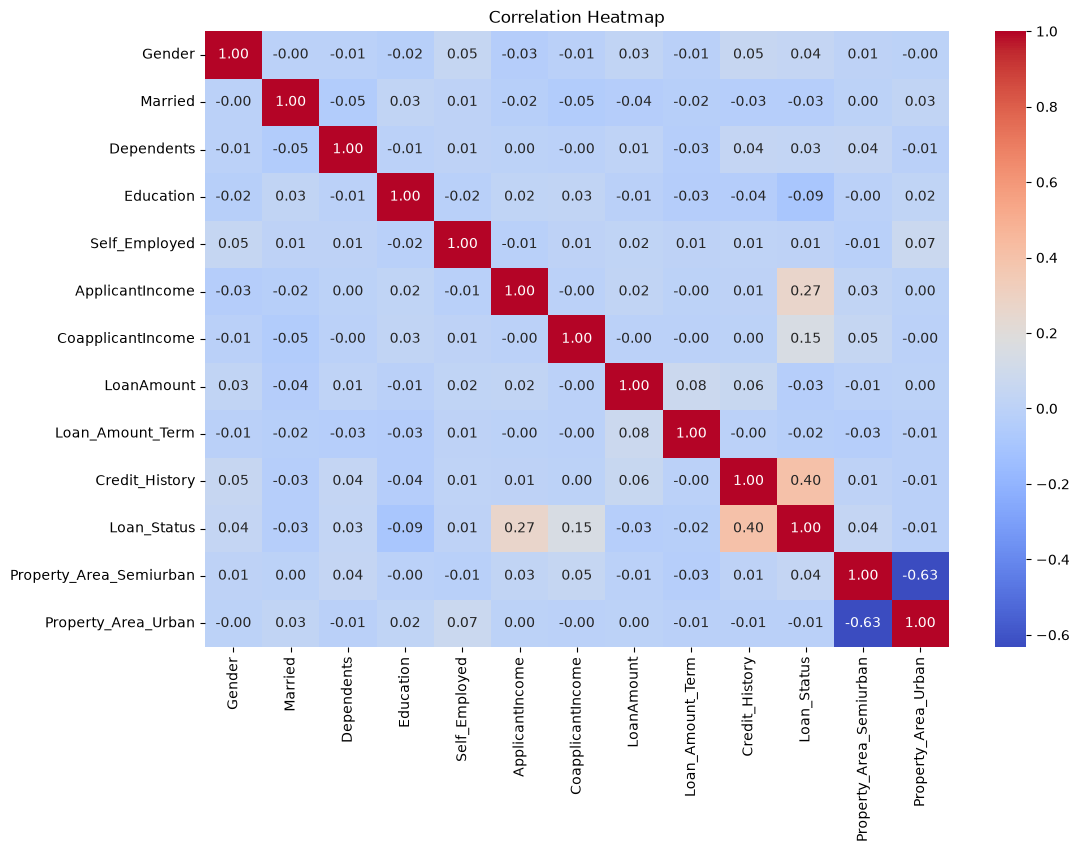

In [29]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm')

plt.title(
    'Correlation Heatmap')

plt.show()

#### Description : Correlation analysis is used to identify the strength and direction of relationships between numerical variables. The correlation heatmap provides a visual representation of these relationships and helps identify variables that are more strongly related to loan approval.

### DISTRIBUTION ANALYSIS

In [30]:
df[numerical_columns].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,13181.560000,7576.474000,369.015000,313.860000,0.838000
std,6850.136059,4372.358649,185.738821,90.437157,0.368635
min,1501.000000,48.000000,50.000000,120.000000,0.000000
25%,7309.250000,3808.000000,210.750000,240.000000,1.000000
50%,13036.000000,7681.000000,364.000000,360.000000,1.000000
75%,18994.750000,11464.500000,523.250000,360.000000,1.000000
max,24988.000000,14993.000000,698.000000,480.000000,1.000000


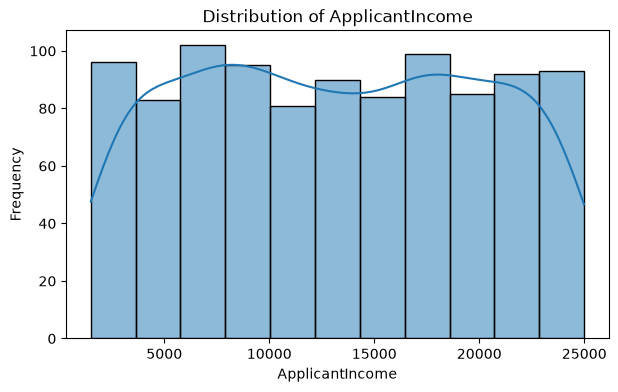

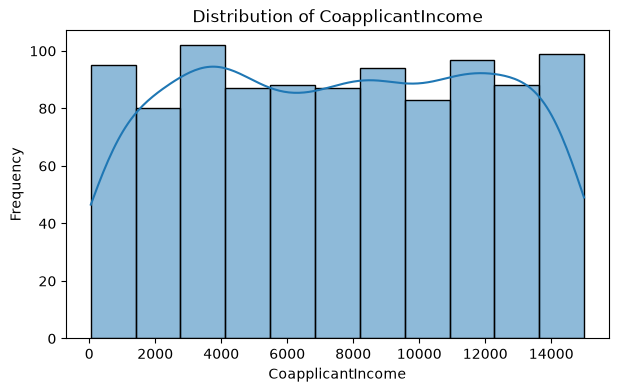

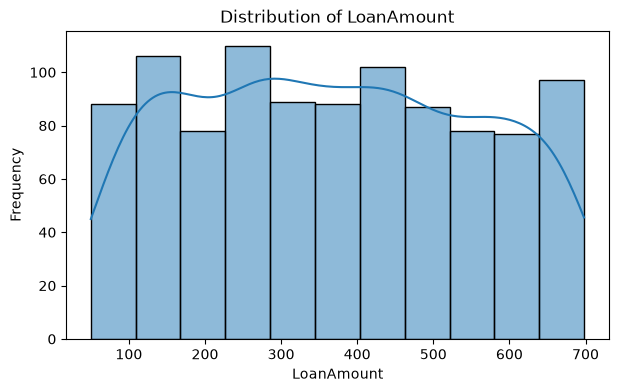

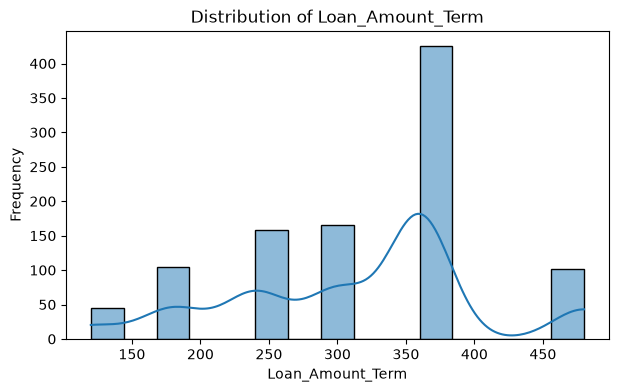

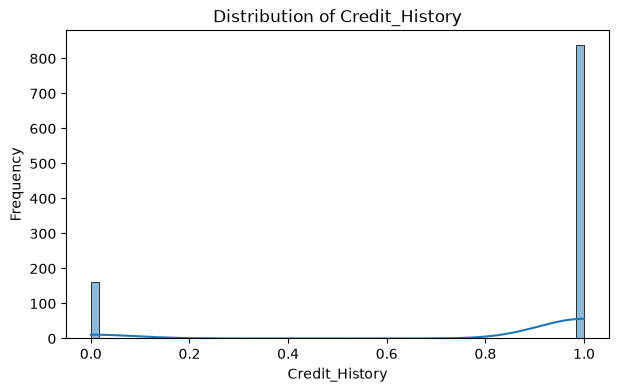

In [31]:
for column in numerical_columns:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        df[column],
        kde=True)

    plt.title(
        f'Distribution of {column}')

    plt.xlabel(column)
    plt.ylabel('Frequency')

    plt.show()

#### Description : Distribution analysis is performed to understand how the numerical variables are distributed. Histograms are used to observe the frequency and spread of variables such as ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, and Credit_History.

### GROUPING AND AGGREGATION

In [32]:
df.groupby(
    'Loan_Status'
)['ApplicantIncome'].mean()

Loan_Status
N     4389.560976
Y    13557.443170
Name: ApplicantIncome, dtype: float64

In [33]:
df.groupby(
    'Loan_Status'
)['LoanAmount'].mean()

Loan_Status
N    397.804878
Y    367.784150
Name: LoanAmount, dtype: float64

In [34]:
df.groupby(
    'Property_Area'
)['ApplicantIncome'].mean()

Property_Area
Rural        12705.106667
Semiurban    13425.578811
Urban        13214.463918
Name: ApplicantIncome, dtype: float64

#### Description : Grouping and aggregation are used to calculate summary values for different categories. The analysis compares average applicant income and loan amount based on loan status and compares average applicant income across different property areas.

### PIVOT TABLE

In [35]:
pivot_table = pd.pivot_table(
    df,
    values='LoanAmount',
    index='Property_Area',
    columns='Loan_Status',
    aggfunc='mean'
)

pivot_table

Loan_Status,N,Y
Property_Area,,
Rural,400.666667,369.079812
Semiurban,320.416667,368.826667
Urban,450.411765,365.986523


#### Description : A pivot table is used to summarize the average LoanAmount based on Property_Area and Loan_Status. It helps compare the average loan amount requested by applicants across different property areas and approval statuses.

## DATA VISUALIZATION

### BAR CHART

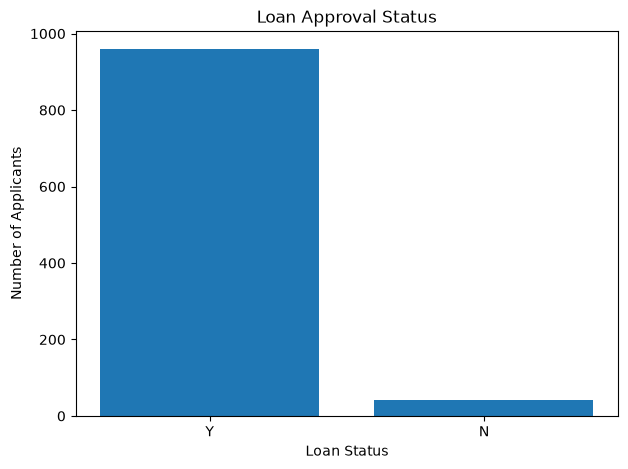

In [36]:
loan_status_counts = df[
    'Loan_Status'
].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    loan_status_counts.index,
    loan_status_counts.values)

plt.title('Loan Approval Status')
plt.xlabel('Loan Status')
plt.ylabel('Number of Applicants')
plt.show()

#### Description : The bar chart shows the number of applicants for each loan approval status. It provides a simple comparison between approved and rejected loan applications.

### HISTOGRAM

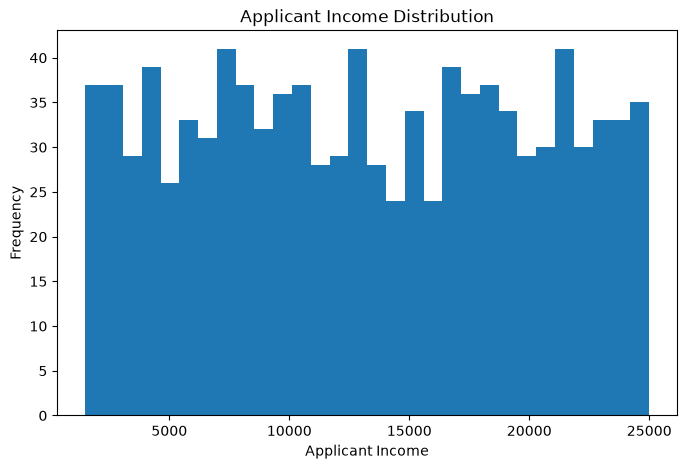

In [37]:
plt.figure(figsize=(8, 5))

plt.hist(
    df['ApplicantIncome'],
    bins=30)

plt.title('Applicant Income Distribution')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')
plt.show()

#### Description : The histogram shows the distribution of ApplicantIncome among the applicants. It helps understand the frequency and spread of applicant income values.

### PIE CHART

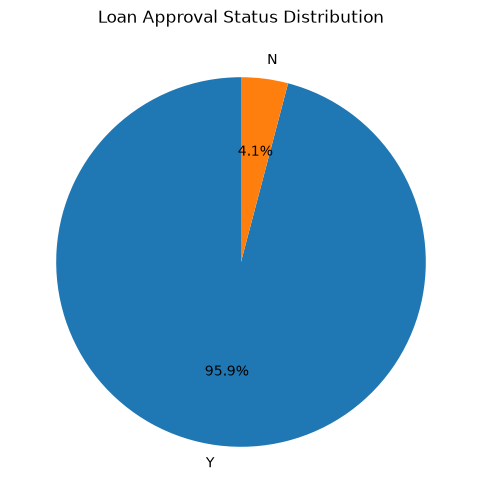

In [38]:
loan_counts = df['Loan_Status'].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    loan_status_counts,
    labels=loan_status_counts.index,
    autopct='%1.1f%%',
    startangle=90)

plt.title('Loan Approval Status Distribution')
plt.show()

#### Description : The pie chart represents the proportion of approved and rejected loan applications. It provides a visual understanding of the distribution of loan approval status in the dataset.

### COUNTPLOT

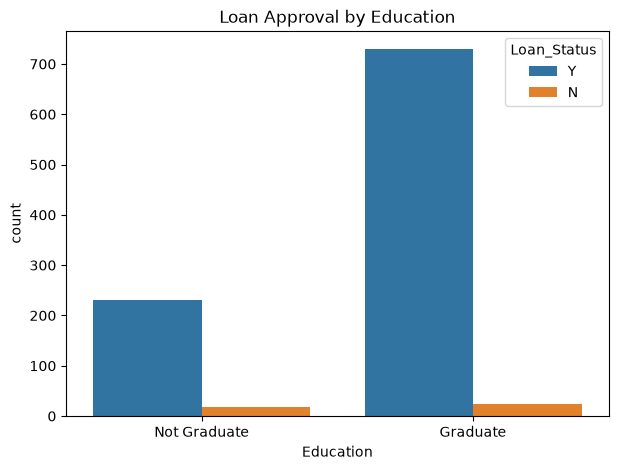

In [39]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Education',
    hue='Loan_Status')

plt.title('Loan Approval by Education')
plt.show()

#### Description : This countplot compares loan approval status across different education categories. It helps understand whether loan approval varies between graduates and non-graduates.

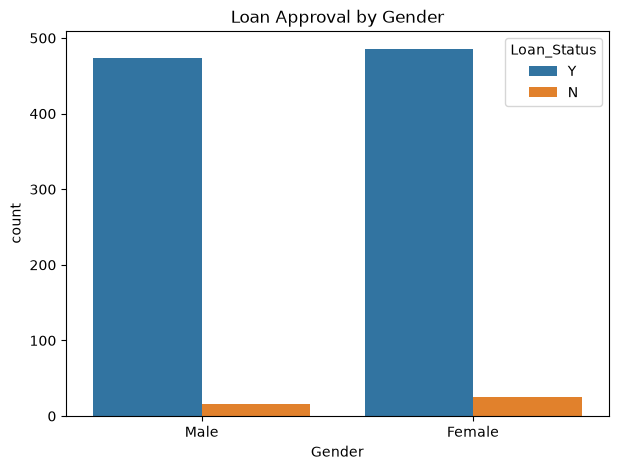

In [40]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Gender',
    hue='Loan_Status')

plt.title('Loan Approval by Gender')

plt.show()

#### Description : This countplot compares loan approval status across different genders. It helps visualize the distribution of approved and rejected applications by gender.

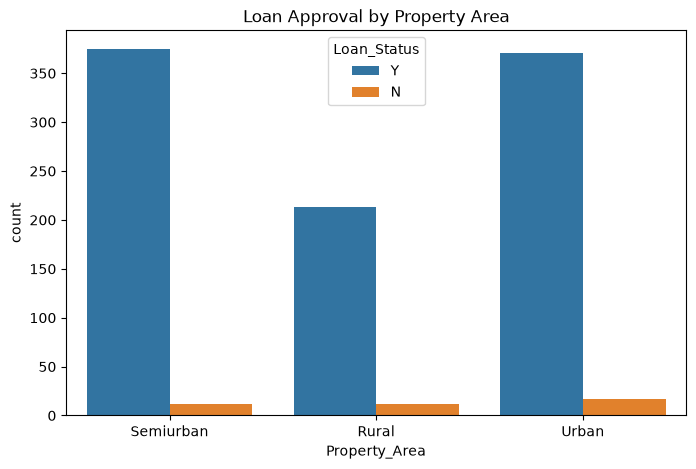

In [41]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Property_Area',
    hue='Loan_Status')

plt.title('Loan Approval by Property Area')

plt.show()

#### Description : This countplot compares loan approval status across Rural, Semiurban, and Urban property areas. It helps identify differences in loan approval distribution based on property area.

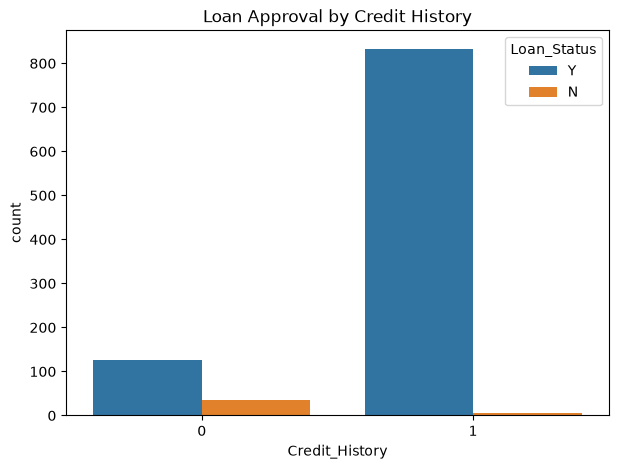

In [42]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Credit_History',
    hue='Loan_Status')

plt.title('Loan Approval by Credit History')

plt.show()

#### Description : This countplot compares loan approval status based on credit history. It helps visualize the relationship between an applicant's credit history and loan approval.

### BOXPLOT

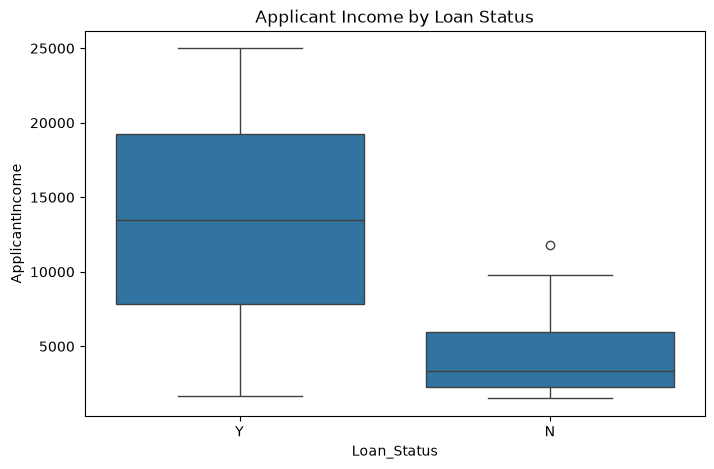

In [43]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Loan_Status',
    y='ApplicantIncome')

plt.title(
    'Applicant Income by Loan Status')

plt.show()

#### Description : The boxplot compares the distribution of ApplicantIncome for approved and rejected loan applications. It helps identify differences in income levels, spread, and possible outliers between the two loan status groups.

### SCATTER PLOT

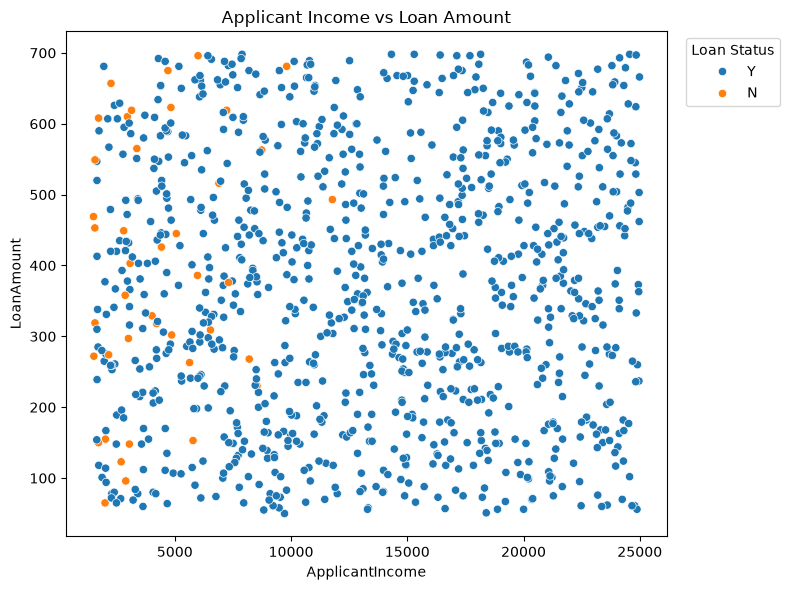

In [44]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='ApplicantIncome',
    y='LoanAmount',
    hue='Loan_Status'
)

plt.title('Applicant Income vs Loan Amount')

plt.legend(
    title='Loan Status',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()

plt.show()

#### Description : The scatter plot shows the relationship between ApplicantIncome and LoanAmount. Loan_Status is used to distinguish the loan approval categories, helping to observe how income and requested loan amount are related.

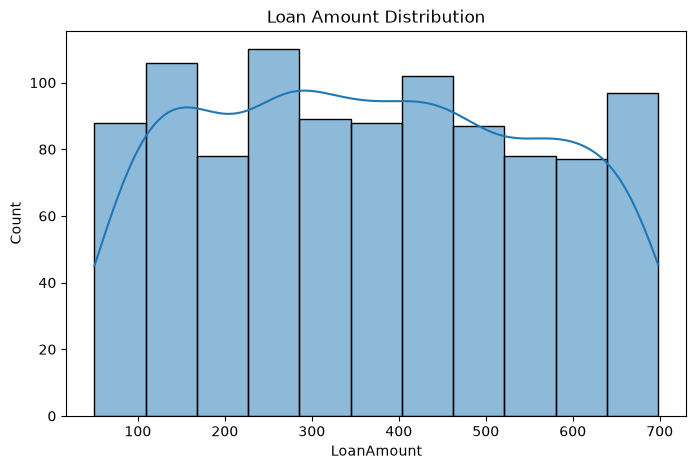

In [45]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='LoanAmount',
    kde=True)

plt.title('Loan Amount Distribution')

plt.show()

#### Description : This histogram shows the distribution of LoanAmount values among the applicants. It helps understand the frequency and spread of the requested loan amounts.

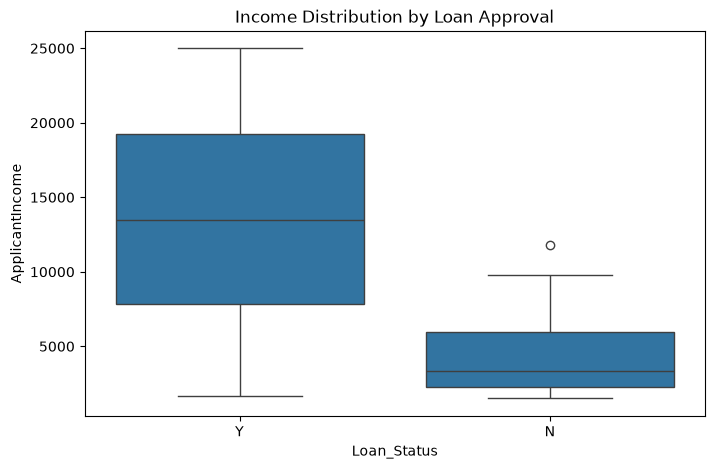

In [46]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Loan_Status',
    y='ApplicantIncome')

plt.title(
    'Income Distribution by Loan Approval')

plt.show()

#### Description : This boxplot compares ApplicantIncome between approved and rejected loan applications. It helps understand how applicant income differs according to loan approval status.

### PLOTLY CHART

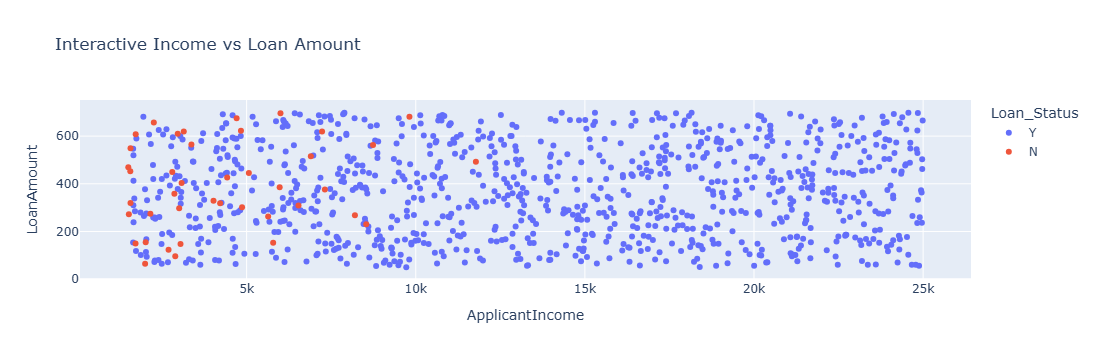

In [47]:
fig = px.scatter(
    df,
    x='ApplicantIncome',
    y='LoanAmount',
    color='Loan_Status',
    title='Interactive Income vs Loan Amount')

fig.show()

#### Description : An interactive scatter plot is created using Plotly to visualize the relationship between ApplicantIncome and LoanAmount. Loan_Status is used as the color category, making the visualization interactive and easier to explore.

## MACHINE LEARNING

In [48]:
ml_df = df.copy()

# Dependents conversion
ml_df['Dependents'] = (
    ml_df['Dependents']
    .replace('3+', '3')
)

ml_df['Dependents'] = pd.to_numeric(
    ml_df['Dependents']
)

# Label Encoding
binary_columns = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Loan_Status'
]

for column in binary_columns:

    encoder = LabelEncoder()

    ml_df[column] = (
        encoder.fit_transform(
            ml_df[column]
        )
    )

# One-Hot Encoding
ml_df = pd.get_dummies(
    ml_df,
    columns=['Property_Area'],
    drop_first=True
)

ml_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,LP100000,1,0,1,1,0,13164,6964,382,120,1,1,True,False
1,LP100001,0,1,1,1,0,9719,13161,50,360,1,1,False,False
2,LP100002,1,1,0,0,0,24964,14635,237,300,1,1,True,False
3,LP100003,1,0,0,1,1,19869,8075,105,360,1,1,True,False
4,LP100004,1,0,0,0,0,11213,13913,596,360,1,1,False,False


In [49]:
ml_df = ml_df.drop(
    'Loan_ID',
    axis=1)

ml_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,1,1,0,13164,6964,382,120,1,1,True,False
1,0,1,1,1,0,9719,13161,50,360,1,1,False,False
2,1,1,0,0,0,24964,14635,237,300,1,1,True,False
3,1,0,0,1,1,19869,8075,105,360,1,1,True,False
4,1,0,0,0,0,11213,13913,596,360,1,1,False,False


In [50]:
X = ml_df.drop(
    'Loan_Status',
    axis=1)

y = ml_df['Loan_Status']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1000, 12)
y Shape: (1000,)


#### Description : The dataset is divided into input features X and target variable y. The input features contain 12 variables, while Loan_Status is used as the target variable for prediction.

### TRAIN-TEST SPLIT

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 12)
X_test: (200, 12)
y_train: (800,)
y_test: (200,)


#### Description : The dataset is divided into 80% training data and 20% testing data. The training data contains 800 records and the testing data contains 200 records. The training data is used to train the models, while the testing data is used to evaluate their performance.

In [52]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train)

X_test_scaled = scaler.transform(
    X_test)

#### Description : StandardScaler is applied to the training and testing features. The scaler is fitted only on the training data and the same transformation is applied to the testing data to maintain consistency.

### LOGISTIC REGRESSION

In [53]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42)

logistic_model.fit(
    X_train_scaled,
    y_train)

y_pred_logistic = (
    logistic_model.predict(
        X_test_scaled
    )
)

In [54]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic)

print(
    "Logistic Regression Accuracy:",
    logistic_accuracy)

Logistic Regression Accuracy: 0.98


#### Description : Logistic Regression is used to predict the loan approval status based on the applicant features. The model achieved an accuracy of 98% on the test data.

### DECISION TREE CLASSIFIER

In [55]:
decision_tree = DecisionTreeClassifier(
    random_state=42)

decision_tree.fit(
    X_train,
    y_train)

y_pred_tree = (
    decision_tree.predict(
        X_test
    )
)

In [56]:
tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree)

print(
    "Decision Tree Accuracy:",
    tree_accuracy)

Decision Tree Accuracy: 0.97


#### Description : The Decision Tree Classifier predicts loan approval by creating decision rules based on the input features. The model achieved an accuracy of 97% on the test data.

### RANDOM FOREST CLASSIFIER

In [57]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42)

random_forest.fit(
    X_train,
    y_train)

y_pred_rf = (
    random_forest.predict(
        X_test
    )
)

In [58]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf)

print(
    "Random Forest Accuracy:",
    rf_accuracy)

Random Forest Accuracy: 0.985


#### Description : The Random Forest Classifier combines multiple decision trees to improve prediction performance. It achieved the highest accuracy of 98.5% among the tested models.

### K-NEAREST NEIGHBORS (KNN)

In [59]:
knn_model = KNeighborsClassifier(
    n_neighbors=5)

knn_model.fit(
    X_train_scaled,
    y_train)

y_pred_knn = (
    knn_model.predict(
        X_test_scaled
    )
)

In [60]:
knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn)

print(
    "KNN Accuracy:",
    knn_accuracy)

KNN Accuracy: 0.955


#### Description : KNN predicts the loan status based on the similarity between applicant records. The model achieved an accuracy of 95.5% on the test data.

## Model Evaluation

### ACCURACY COMPARISON

In [61]:
accuracy_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],

    'Accuracy': [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy,
        knn_accuracy
    ]
})

accuracy_comparison

,Model,Accuracy
0,Logistic Regression,0.980
1,Decision Tree,0.970
2,Random Forest,0.985
3,KNN,0.955


#### Description : The accuracy of the four machine learning models is compared. Random Forest achieved the highest accuracy of 98.5%, followed by Logistic Regression with 98%, Decision Tree with 97%, and KNN with 95.5%.

### MODEL PERFORMANCE COMPARISON

In [62]:
accuracy_comparison.sort_values(
    by='Accuracy',
    ascending=False)

,Model,Accuracy
2,Random Forest,0.985
0,Logistic Regression,0.980
1,Decision Tree,0.970
3,KNN,0.955


#### Description : The models are sorted according to their accuracy in descending order. Random Forest is ranked first with an accuracy of 98.5%, making it the best-performing model based on accuracy.

### PRECISION, RECALL AND F1 SCORE

In [63]:
model_predictions = {
    'Logistic Regression': y_pred_logistic,
    'Decision Tree': y_pred_tree,
    'Random Forest': y_pred_rf,
    'KNN': y_pred_knn
}

results = []

for model_name, predictions in model_predictions.items():

    results.append({
        'Model': model_name,

        'Accuracy': accuracy_score(
            y_test,
            predictions
        ),

        'Precision': precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        'Recall': recall_score(
            y_test,
            predictions,
            zero_division=0
        ),

        'F1 Score': f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

evaluation_results = pd.DataFrame(
    results
)

evaluation_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.980,0.979592,1.000000,0.989691
1,Decision Tree,0.970,0.984375,0.984375,0.984375
2,Random Forest,0.985,0.984615,1.000000,0.992248
3,KNN,0.955,0.964467,0.989583,0.976864


#### Description : Accuracy, Precision, Recall, and F1-score are used to evaluate the classification performance of the machine learning models. These metrics provide a detailed understanding of how accurately the models classify loan applications.

### CONFUSION MATRIX

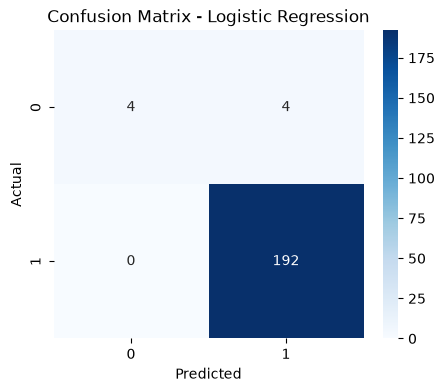

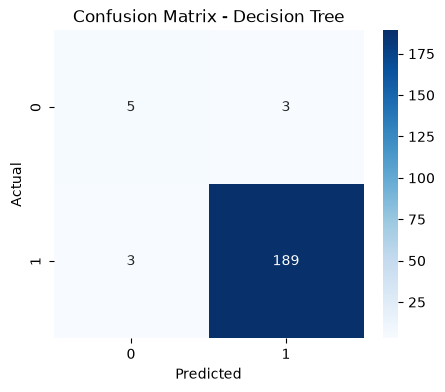

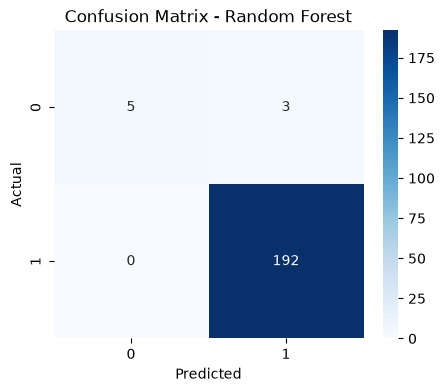

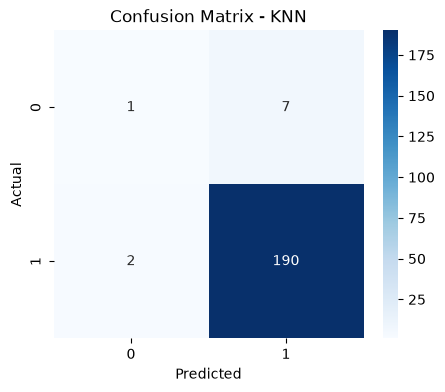

In [64]:
for model_name, predictions in model_predictions.items():

    cm = confusion_matrix(
        y_test,
        predictions)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues')

    plt.title(
        f'Confusion Matrix - {model_name}')

    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

#### Description : The confusion matrix shows the number of correctly and incorrectly classified loan applications. It helps evaluate the model's prediction performance for approved and rejected loan applications.

### ROC CURVE

In [65]:
logistic_prob = (
    logistic_model.predict_proba(
        X_test_scaled
    )[:, 1])

tree_prob = (
    decision_tree.predict_proba(
        X_test
    )[:, 1])

rf_prob = (
    random_forest.predict_proba(
        X_test
    )[:, 1])

knn_prob = (
    knn_model.predict_proba(
        X_test_scaled
    )[:, 1])

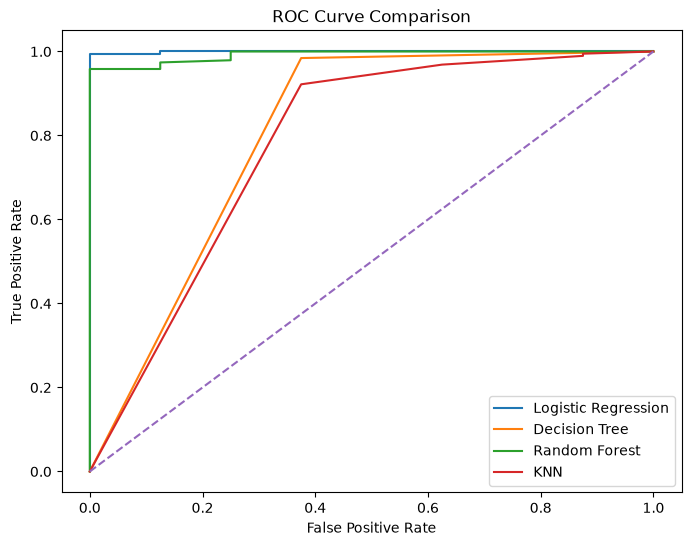

In [66]:
fpr_log, tpr_log, _ = roc_curve(
    y_test,
    logistic_prob)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    tree_prob)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_prob)

fpr_knn, tpr_knn, _ = roc_curve(
    y_test,
    knn_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label='Logistic Regression')

plt.plot(
    fpr_tree,
    tpr_tree,
    label='Decision Tree')

plt.plot(
    fpr_rf,
    tpr_rf,
    label='Random Forest')

plt.plot(
    fpr_knn,
    tpr_knn,
    label='KNN')

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--')

plt.xlabel(
    'False Positive Rate')

plt.ylabel(
    'True Positive Rate')

plt.title(
    'ROC Curve Comparison')

plt.legend()

plt.show()

#### Description : The ROC curve evaluates the ability of the Random Forest model to distinguish between approved and rejected loan applications. The AUC value represents the overall classification performance of the model.

In [67]:
auc_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],

    'ROC-AUC': [
        roc_auc_score(
            y_test,
            logistic_prob
        ),

        roc_auc_score(
            y_test,
            tree_prob
        ),

        roc_auc_score(
            y_test,
            rf_prob
        ),

        roc_auc_score(
            y_test,
            knn_prob
        )
    ]
})

auc_results

,Model,ROC-AUC
0,Logistic Regression,0.999349
1,Decision Tree,0.804688
2,Random Forest,0.991862
3,KNN,0.778646


### FINAL RESULT

In [68]:
final_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],

    'Accuracy': [
        accuracy_score(
            y_test,
            y_pred_logistic
        ),
        accuracy_score(
            y_test,
            y_pred_tree
        ),
        accuracy_score(
            y_test,
            y_pred_rf
        ),
        accuracy_score(
            y_test,
            y_pred_knn
        )
    ],

    'Precision': [
        precision_score(
            y_test,
            y_pred_logistic,
            zero_division=0
        ),
        precision_score(
            y_test,
            y_pred_tree,
            zero_division=0
        ),
        precision_score(
            y_test,
            y_pred_rf,
            zero_division=0
        ),
        precision_score(
            y_test,
            y_pred_knn,
            zero_division=0
        )
    ],

    'Recall': [
        recall_score(
            y_test,
            y_pred_logistic,
            zero_division=0
        ),
        recall_score(
            y_test,
            y_pred_tree,
            zero_division=0
        ),
        recall_score(
            y_test,
            y_pred_rf,
            zero_division=0
        ),
        recall_score(
            y_test,
            y_pred_knn,
            zero_division=0
        )
    ],

    'F1 Score': [
        f1_score(
            y_test,
            y_pred_logistic,
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred_tree,
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred_rf,
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred_knn,
            zero_division=0
        )
    ],

    'ROC-AUC': [
        roc_auc_score(
            y_test,
            logistic_prob
        ),
        roc_auc_score(
            y_test,
            tree_prob
        ),
        roc_auc_score(
            y_test,
            rf_prob
        ),
        roc_auc_score(
            y_test,
            knn_prob
        )
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.980,0.979592,1.000000,0.989691,0.999349
1,Decision Tree,0.970,0.984375,0.984375,0.984375,0.804688
2,Random Forest,0.985,0.984615,1.000000,0.992248,0.991862
3,KNN,0.955,0.964467,0.989583,0.976864,0.778646


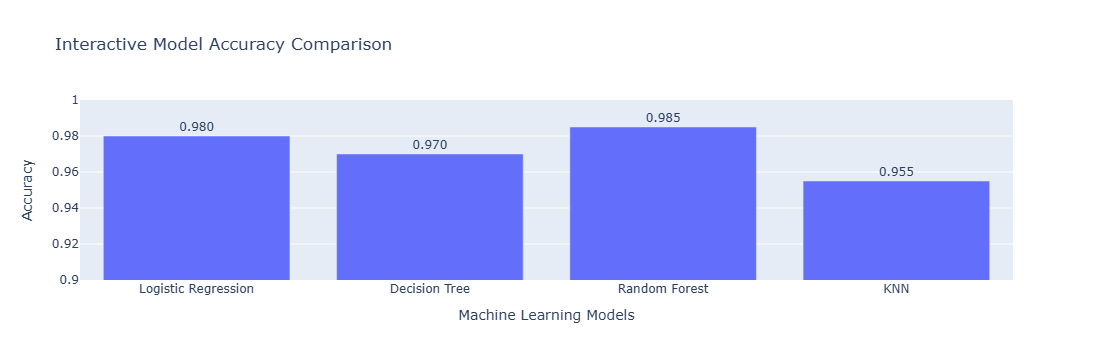

In [69]:
# Interactive Model Accuracy Comparison

import plotly.express as px

fig = px.bar(
    final_results,
    x='Model',
    y='Accuracy',
    title='Interactive Model Accuracy Comparison',
    text='Accuracy'
)

fig.update_traces(
    texttemplate='%{text:.3f}',
    textposition='outside'
)

fig.update_yaxes(
    range=[0.90, 1.00],
    title='Accuracy'
)

fig.update_xaxes(
    title='Machine Learning Models'
)

fig.show()

In [70]:
best_model = final_results.loc[
    final_results['Accuracy'].idxmax()
]

print(
    "Best Model:",
    best_model['Model']
)

print(
    "Best Accuracy:",
    best_model['Accuracy']
)

Best Model: Random Forest
Best Accuracy: 0.985


In [71]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': random_forest.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

feature_importance

,Feature,Importance
5,ApplicantIncome,0.374713
9,Credit_History,0.202564
6,CoapplicantIncome,0.168418
7,LoanAmount,0.094279
8,Loan_Amount_Term,0.031439
2,Dependents,0.028805
3,Education,0.028700
1,Married,0.018260
0,Gender,0.016425
11,Property_Area_Urban,0.013859


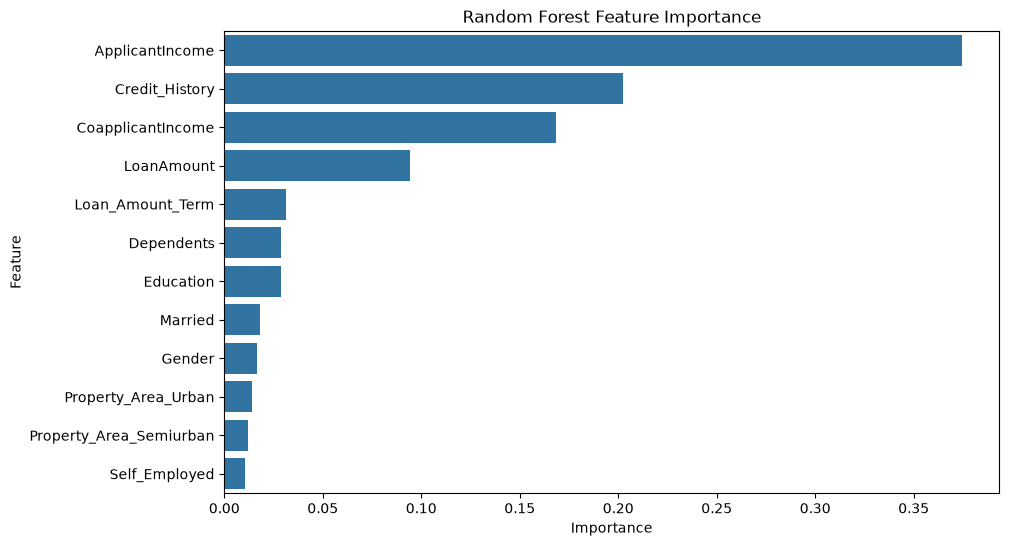

In [72]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature')

plt.title(
    'Random Forest Feature Importance')

plt.show()

In [73]:
credit_approval = pd.crosstab(
    df['Credit_History'],
    df['Loan_Status'],
    normalize='index'
) * 100

credit_approval

Loan_Status,N,Y
Credit_History,,
0,22.222222,77.777778
1,0.596659,99.403341


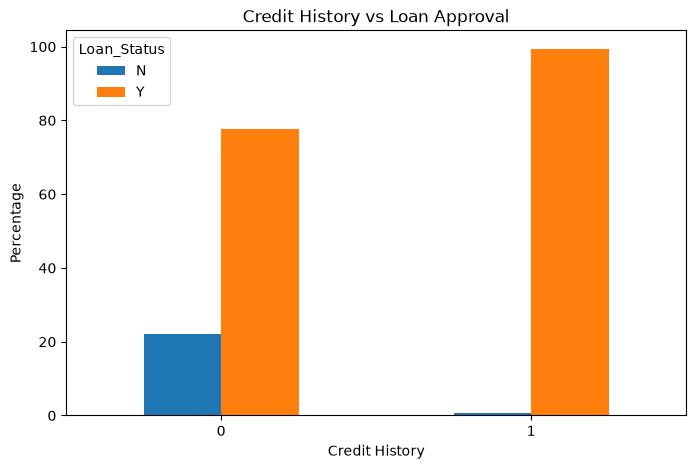

In [74]:
credit_approval.plot(
    kind='bar',
    figsize=(8,5))

plt.xlabel('Credit History')
plt.ylabel('Percentage')
plt.title('Credit History vs Loan Approval')
plt.xticks(rotation=0)

plt.show()

#### Description : The graph shows the relationship between Credit History and Loan Approval. Applicants with a positive credit history have a higher likelihood of getting their loans approved. This indicates that credit history is an important factor in loan approval.

In [75]:
property_approval = pd.crosstab(
    df['Property_Area'],
    df['Loan_Status'],
    normalize='index'
) * 100

property_approval

Loan_Status,N,Y
Property_Area,,
Rural,5.333333,94.666667
Semiurban,3.100775,96.899225
Urban,4.381443,95.618557


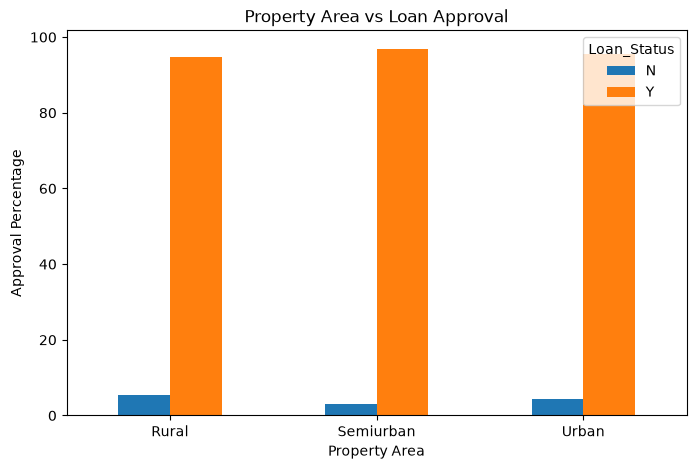

In [76]:
property_approval.plot(
    kind='bar',
    figsize=(8,5))

plt.xlabel('Property Area')
plt.ylabel('Approval Percentage')
plt.title('Property Area vs Loan Approval')
plt.xticks(rotation=0)

plt.show()

#### Description : The graph shows the relationship between Property Area and Loan Approval. It helps to compare loan approval patterns across different property areas such as Rural, Semiurban, and Urban.

In [77]:
income_approval = df.groupby(
    'Loan_Status'
)['ApplicantIncome'].mean()

income_approval

Loan_Status
N     4389.560976
Y    13557.443170
Name: ApplicantIncome, dtype: float64

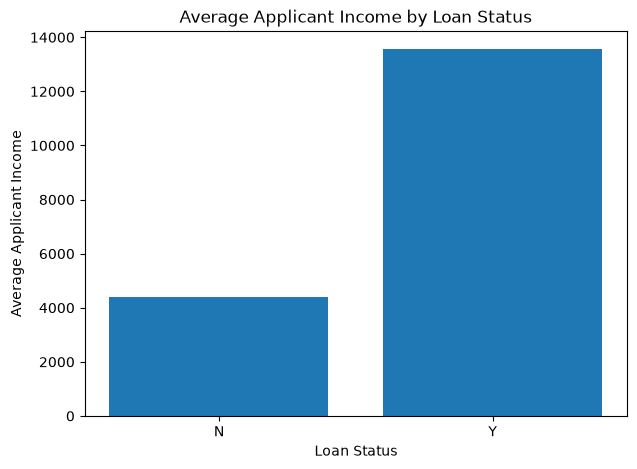

In [78]:
plt.figure(figsize=(7,5))

plt.bar(
    income_approval.index,
    income_approval.values)

plt.xlabel('Loan Status')
plt.ylabel('Average Applicant Income')
plt.title('Average Applicant Income by Loan Status')

plt.show()

#### Description : The diagram represents the overall loan approval prediction process, starting from applicant information and data preprocessing, followed by machine learning prediction and the final loan approval decision.

In [79]:
sample_application = X.iloc[[0]]

print("Sample Applicant Details:")
print(sample_application)

Sample Applicant Details:
   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           1          1              0            13164   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0               6964         382               120               1   

   Property_Area_Semiurban  Property_Area_Urban  
0                     True                False  


#### Description : The sample applicant details are selected from the input features and displayed for prediction. These details include gender, marital status, dependents, education, employment status, income, loan amount, loan term, credit history, and property area.


In [80]:
sample_application = X.iloc[[0]]

rf_prediction = random_forest.predict(sample_application)

if rf_prediction[0] == 1:
    print("Loan Status: APPROVED")
else:
    print("Loan Status: REJECTED")

Loan Status: APPROVED


#### Description : The Random Forest model predicts that the given loan application is approved based on the applicant's input details.

In [81]:
print("===== FINAL MODEL COMPARISON =====")
print()

print(evaluation_results.to_string(index=False))

print()

print("Best Model based on Accuracy:",
      evaluation_results.loc[
          evaluation_results['Accuracy'].idxmax(),
          'Model'
      ])

print("Best Accuracy:",
      evaluation_results['Accuracy'].max())

===== FINAL MODEL COMPARISON =====

              Model  Accuracy  Precision   Recall  F1 Score
Logistic Regression     0.980   0.979592 1.000000  0.989691
      Decision Tree     0.970   0.984375 0.984375  0.984375
      Random Forest     0.985   0.984615 1.000000  0.992248
                KNN     0.955   0.964467 0.989583  0.976864

Best Model based on Accuracy: Random Forest
Best Accuracy: 0.985


#### Description : The final model comparison summarizes the performance of all four machine learning models using Accuracy, Precision, Recall, and F1 Score. Random Forest achieved the highest accuracy of 0.985 (98.5%), making it the best-performing model based on accuracy. Logistic Regression achieved 98%, Decision Tree achieved 97%, and KNN achieved 95.5% accuracy.
